# 02 — Trénink U-Net

U-Net je **konvoluční baseline** celé studie. Trénuje se od nuly na datech
připravených v notebooku 01.

Teorie: [`devnotes/teorie/01_konvoluce_a_unet.md`](../devnotes/teorie/01_konvoluce_a_unet.md)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))
from _common import *
import cv2, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
print("repo:", REPO_ROOT)

repo: C:\GitHub\USU-zapocet


## 1. Konfigurace

Všechny hyperparametry jsou v `training/configs/unet.yaml`. UNETR má vlastní
config se **stejnými** hodnotami všude kromě názvu běhu, počtu epoch a learning
rate — to je podmínka kontrolovaného experimentu: liší se jen architektura.

In [2]:
import yaml
cfg = yaml.safe_load((REPO_ROOT / "training/configs/unet.yaml").read_text(encoding="utf-8"))
print(yaml.dump(cfg, allow_unicode=True, sort_keys=False))

run:
  name: unet-atlas-v1
  seed: 42
  max_epochs: 60
  full_val_every: 5
  max_minutes: null
data:
  patch_size: 256
  patches_per_image: 8
  train_batch_size: 8
  num_workers: 8
  heqv: true
  use_precomputed_heqv: true
optimizer:
  lr: 0.001
scheduler:
  kind: cosine
  t0: 5
  t_mult: 2
  eta_min: 1.0e-08
  plateau_patience: 5
  plateau_ratio: 0.8
transforms:
  rand_flip_prob: 0.5
  rand_rotate90_prob: 0.5
  rand_rotate90_max_k: 3
  rand_zoom_min: 0.9
  rand_zoom_max: 1.1
  rand_zoom_prob: 0.3
  rand_gaussian_noise_prob: 0.2
validation:
  sw_batch_size: 4
  sw_overlap: 0.25
amp: true



### Poznámka k learning rate

Původní vypůjčený repozitář používal `lr = 0.01`. Při ověřování se ukázalo, že
s naší konfigurací (patch 256, batch 8, mixed precision) **U-Net po zhruba 200
krocích zdiverguje na `loss = nan`**. Hodnota je proto snížená na `1e-3`
(standard pro optimalizátor Adam).

Je to praktická ilustrace toho, že hyperparametry se nedají přebírat mezi
konfiguracemi bez ověření. Trénovací smyčka má kvůli tomu i pojistku, která
divergenci pozná a běh zastaví s jasnou hláškou — bez ní by osmihodinový noční
běh vyprodukoval bezcenný model a zjistilo by se to až ráno.

## 2. Architektura

Vstup má 3 kanály (rentgen je šedotónový, kanál se ztrojí kvůli shodě
s konfigurací původního repozitáře), výstup 7 kanálů — jeden na třídu.

In [3]:
import torch
from training.common.models import build_unet

model = build_unet()
n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net — počet parametrů: {n_params/1e6:.2f} M")

x = torch.randn(1, 3, 256, 256)
print("vstup :", tuple(x.shape))
print("výstup:", tuple(model(x).shape), "  (7 kanálů = 7 tříd)")

U-Net — počet parametrů: 1.63 M
vstup : (1, 3, 256, 256)
výstup: (1, 7, 256, 256)   (7 kanálů = 7 tříd)


In [4]:
# Kontrola hardwaru — bez GPU by trénink trval řádově déle
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name}, VRAM {p.total_memory/1e9:.2f} GB")
    print("torch:", torch.__version__)

CUDA: True


GPU: NVIDIA GeForce RTX 3060 Laptop GPU, VRAM 6.44 GB
torch: 2.11.0+cu128


## 3. Rychlý test průchodnosti

Než se pustí několikahodinový běh, ověříme na hrstce snímků, že celý řetěz
funguje. Trvá to zhruba minutu.

Použitý `--no-resume` zajistí, že se nenaváže na starší checkpoint.

In [5]:
run_script("training/train_unet.py", "--max-epochs", "2",
           "--limit-train", "40", "--limit-val", "4", "--no-resume")

$ py -3 -u training/train_unet.py --max-epochs 2 --limit-train 40 --limit-val 4 --no-resume



[train_unet] run=unet-atlas-v1 train_batches/epoch=40 val_images=4


[hw] GPU: NVIDIA GeForce RTX 3060 Laptop GPU | VRAM 6.44 GB | torch 2.11.0+cu128 | AMP zapnuto


[unet-atlas-v1] epoch 0: loss=2.0396 train_dice=0.0156 val_dice=- lr=1.00e-03


[unet-atlas-v1] epoch 1: loss=1.3168 train_dice=0.0000 val_dice=0.0000 lr=9.05e-04


[train_unet] hotovo: {'best_val_dice': 0.0, 'last_epoch': 1, 'stopped_reason': 'max_epochs_reached'}



[navratovy kod: 0]


0

## 4. Ostrý trénink

⚠️ **Dlouhý běh** — naměřeno ~2,6 min na epochu, tedy zhruba 2,6 h pro 60 epoch.

Trénink je **přerušitelný**:
- checkpoint se ukládá po každé epoše, takže přerušení stojí nanejvýš
  rozpracovanou epochu
- `--resume` (výchozí) najde poslední checkpoint a naváže
- `--max-minutes` je časový rozpočet jednoho spuštění — hodí se, když je grafika
  k dispozici jen v nočním okně

Buňka je záměrně zakomentovaná, aby se dlouhý běh nespustil omylem.

In [6]:
# ODKOMENTUJ pro ostrý trénink:
# run_script("training/train_unet.py", "--max-minutes", "180")

print("Spouštět raději z terminálu, ať notebook nedrží běh:")
print("  py -3 -u training/train_unet.py --max-minutes 180")

Spouštět raději z terminálu, ať notebook nedrží běh:
  py -3 -u training/train_unet.py --max-minutes 180


## 5. Průběh tréninku

Smyčka zapisuje metriky do TensorBoardu. Načteme je přímo, ať je průběh vidět
v notebooku.

Validační Dice se počítá jen každou 5. epochu — plná sliding-window inference
přes celé snímky je řádově dražší než tréninkový krok na výřezu.

In [7]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def load_curves(run_name):
    run_dir = OUTPUTS_DIR / "runs" / run_name
    if not run_dir.exists():
        print(f"Log {run_dir} zatím neexistuje — nejdřív trénink."); return {}
    acc = EventAccumulator(str(run_dir)); acc.Reload()
    return {tag: ([e.step for e in acc.Scalars(tag)], [e.value for e in acc.Scalars(tag)])
            for tag in acc.Tags()["scalars"]}

curves = load_curves("unet-atlas-v1")
print("dostupné metriky:", list(curves))

dostupné metriky: ['Loss/train', 'Dice/train', 'LR', 'Dice/val']


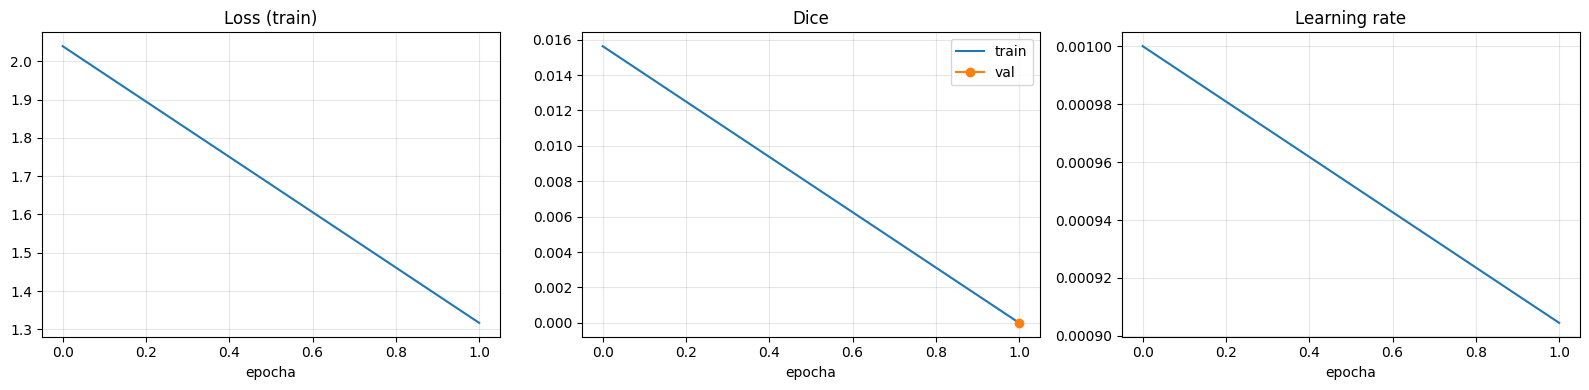

In [8]:
if curves:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    if "Loss/train" in curves:
        ax[0].plot(*curves["Loss/train"]); ax[0].set_title("Loss (train)")
    if "Dice/train" in curves:
        ax[1].plot(*curves["Dice/train"], label="train")
    if "Dice/val" in curves:
        ax[1].plot(*curves["Dice/val"], "o-", label="val")
    ax[1].set_title("Dice"); ax[1].legend()
    if "LR" in curves:
        ax[2].plot(*curves["LR"]); ax[2].set_title("Learning rate")
    for a in ax: a.set_xlabel("epocha"); a.grid(alpha=.3)
    plt.tight_layout(); plt.show()

**Jak číst křivky:**
- *Loss klesá, Dice roste* → model se učí
- *train Dice roste, val Dice stagnuje nebo klesá* → přetrénování; použije se
  checkpoint `-best.pth`, který se ukládá podle nejlepšího validačního Dice
- *pilovité LR* → scheduler `CosineAnnealingWarmRestarts` periodicky restartuje
  learning rate, což pomáhá vyskočit z mělkých lokálních minim

➡️ Dál: [`03_trenink_unetr.ipynb`](03_trenink_unetr.ipynb)